In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("retail_sales_2024.csv")


df["order_date"] = pd.to_datetime(df["order_date"])
df["month"] = df["order_date"].dt.month
df["quarter"] = df["order_date"].dt.quarter
df["profit_margin"] = df["profit"] / df["revenue"] * 100

print(df.shape)
print(df.info())
print("Missing values:", df.isna().sum().sum())
display(df.head())


(1000, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   order_id         1000 non-null   object        
 1   order_date       1000 non-null   datetime64[ns]
 2   region           1000 non-null   object        
 3   category         1000 non-null   object        
 4   product          1000 non-null   object        
 5   quantity         1000 non-null   int64         
 6   unit_price       1000 non-null   float64       
 7   discount         1000 non-null   float64       
 8   revenue          1000 non-null   float64       
 9   profit           1000 non-null   float64       
 10  customer_age     1000 non-null   int64         
 11  customer_gender  1000 non-null   object        
 12  payment_method   1000 non-null   object        
 13  delivery_days    1000 non-null   int64         
 14  rating           1000 non-null

,order_id,order_date,region,category,product,quantity,unit_price,discount,revenue,profit,customer_age,customer_gender,payment_method,delivery_days,rating,month,quarter,profit_margin
0,ORD1001,2024-01-01,West,Clothing,Jeans,4,1730.0,0.00,6920.0,2636.14,45,Male,Debit Card,3,3.0,1,1,38.094509
1,ORD1002,2024-01-01,South,Sports,Dumbbell Set,1,2360.0,0.00,2360.0,690.43,39,Female,Credit Card,2,4.0,1,1,29.255508
2,ORD1003,2024-01-02,East,Clothing,T-Shirt,2,680.0,0.00,1360.0,456.07,31,Male,Credit Card,5,4.0,1,1,33.534559
3,ORD1004,2024-01-02,East,Clothing,Sneakers,3,2760.0,0.30,5796.0,887.30,24,Female,Credit Card,4,5.0,1,1,15.308834
4,ORD1005,2024-01-03,South,Clothing,Sneakers,2,2810.0,0.05,5339.0,1531.46,54,Female,UPI,2,3.0,1,1,28.684398


### Q1. Line Plot: Monthly Revenue

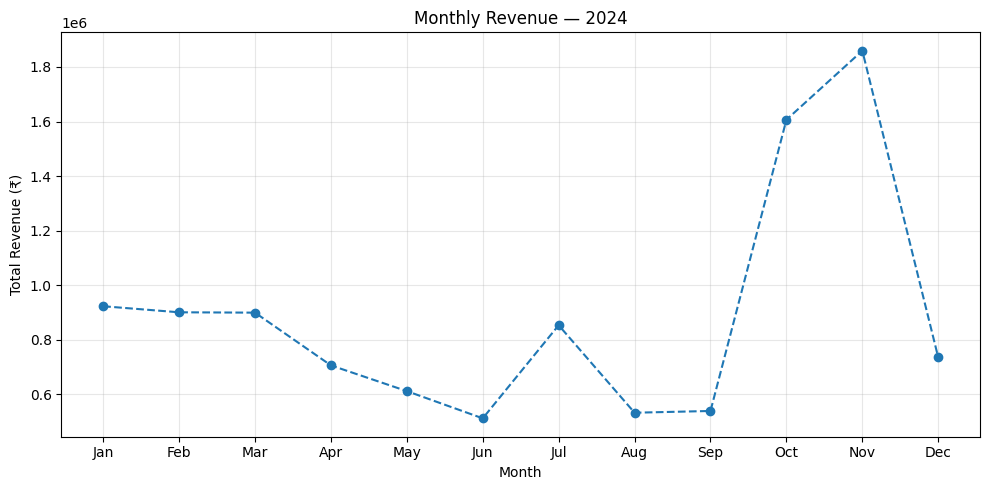

In [8]:
monthly_revenue = df.groupby("month")["revenue"].sum().reindex(range(1, 13), fill_value=0)
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

plt.figure(figsize=(10, 5))
plt.plot(month_names, monthly_revenue.values, marker="o", linestyle="--")
plt.xlabel("Month")
plt.ylabel("Total Revenue (₹)")
plt.title("Monthly Revenue — 2024")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Q2. Bar Chart: Revenue by Category

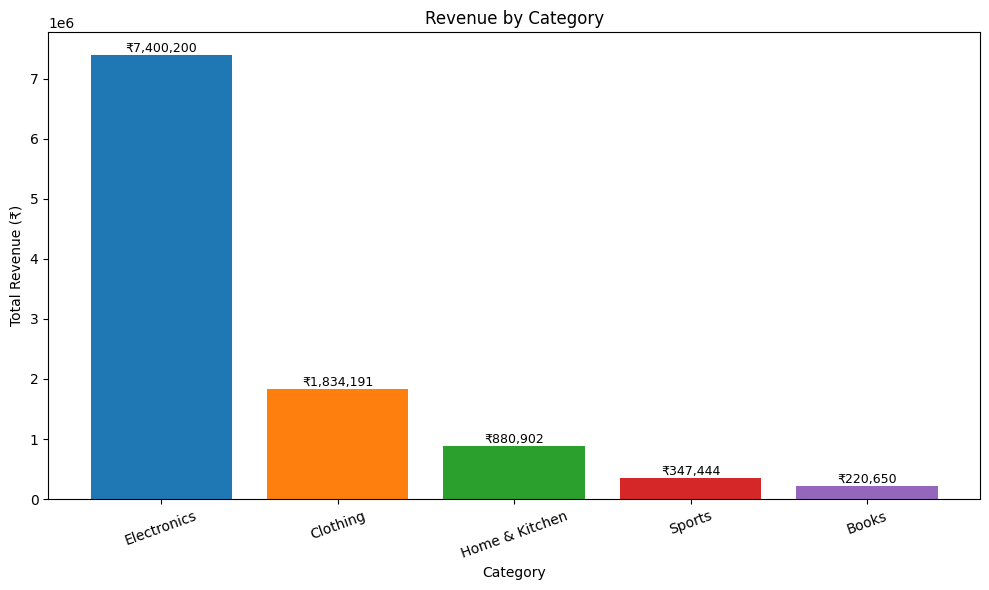

In [9]:
category_revenue = df.groupby("category")["revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(category_revenue.index, category_revenue.values,
               color=plt.cm.tab10(np.arange(len(category_revenue))))
plt.xlabel("Category")
plt.ylabel("Total Revenue (₹)")
plt.title("Revenue by Category")
plt.xticks(rotation=20)

for bar, value in zip(bars, category_revenue.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"₹{value:,.0f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


### Q3. Horizontal Bar Chart: Top 10 Products by Profit

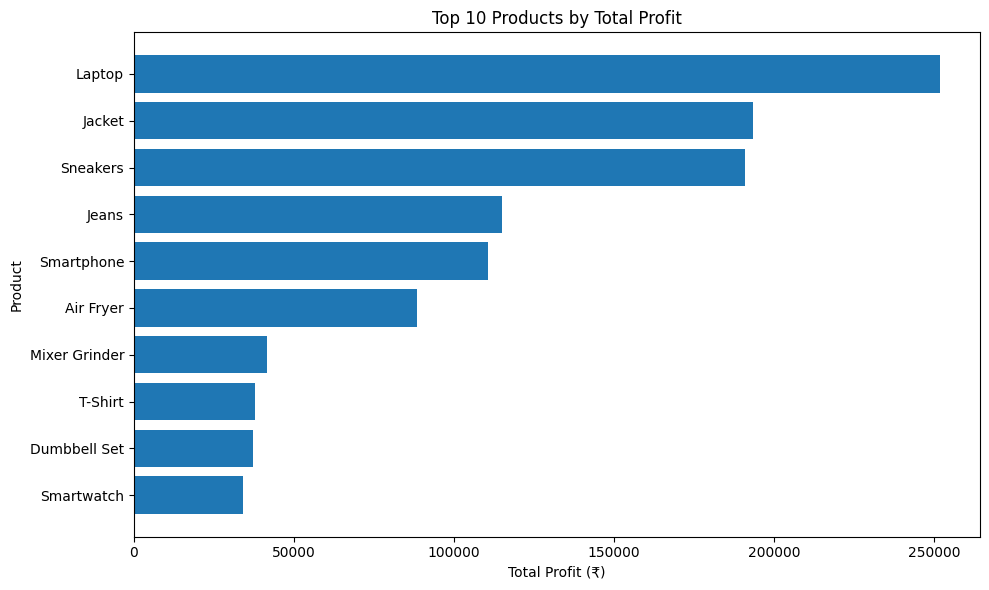

In [10]:
top10_products = df.groupby("product")["profit"].sum().sort_values(ascending=False).head(10).sort_values()

plt.figure(figsize=(10, 6))
plt.barh(top10_products.index, top10_products.values)
plt.xlabel("Total Profit (₹)")
plt.ylabel("Product")
plt.title("Top 10 Products by Total Profit")
plt.tight_layout()
plt.show()


### Q4. Pie Chart: Payment Methods

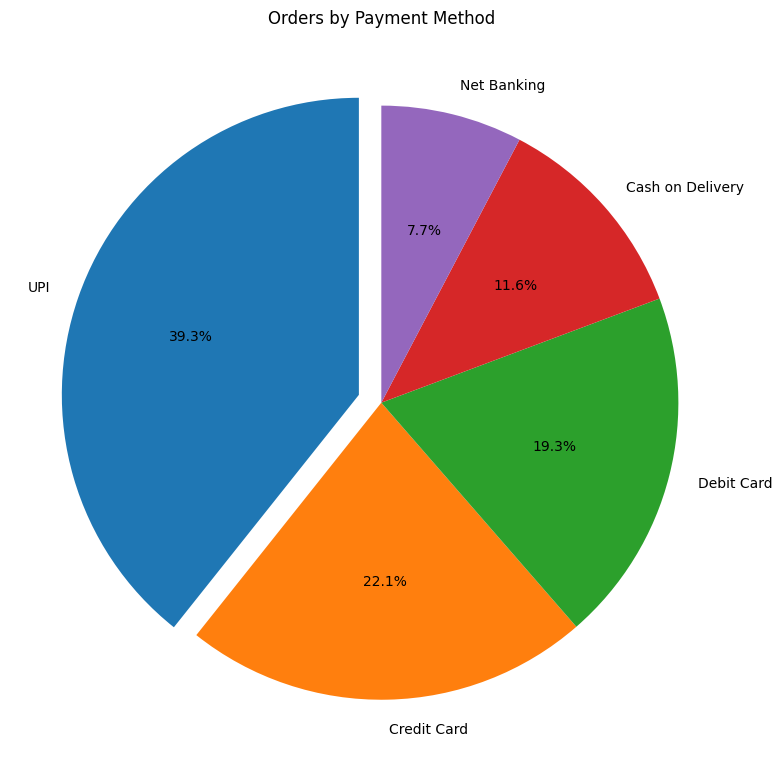

In [11]:
payment_counts = df["payment_method"].value_counts()
largest_index = int(np.argmax(payment_counts.values))
explode = [0.08 if i == largest_index else 0 for i in range(len(payment_counts))]

plt.figure(figsize=(8, 8))
plt.pie(payment_counts.values, labels=payment_counts.index,
        autopct="%.1f%%", explode=explode, startangle=90)
plt.title("Orders by Payment Method")
plt.tight_layout()
plt.show()


### Q5. Histogram: Customer Age

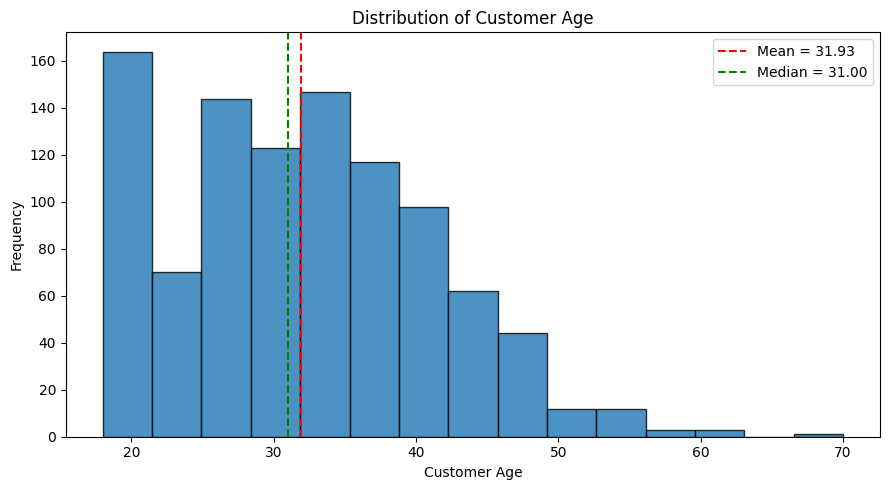

In [12]:
mean_age = df["customer_age"].mean()
median_age = df["customer_age"].median()

plt.figure(figsize=(9, 5))
plt.hist(df["customer_age"], bins=15, edgecolor="black", alpha=0.8)
plt.axvline(mean_age, color="red", linestyle="--", label=f"Mean = {mean_age:.2f}")
plt.axvline(median_age, color="green", linestyle="--", label=f"Median = {median_age:.2f}")
plt.xlabel("Customer Age")
plt.ylabel("Frequency")
plt.title("Distribution of Customer Age")
plt.legend()
plt.tight_layout()
plt.show()


### Q6. Scatter Plot: Revenue vs Profit

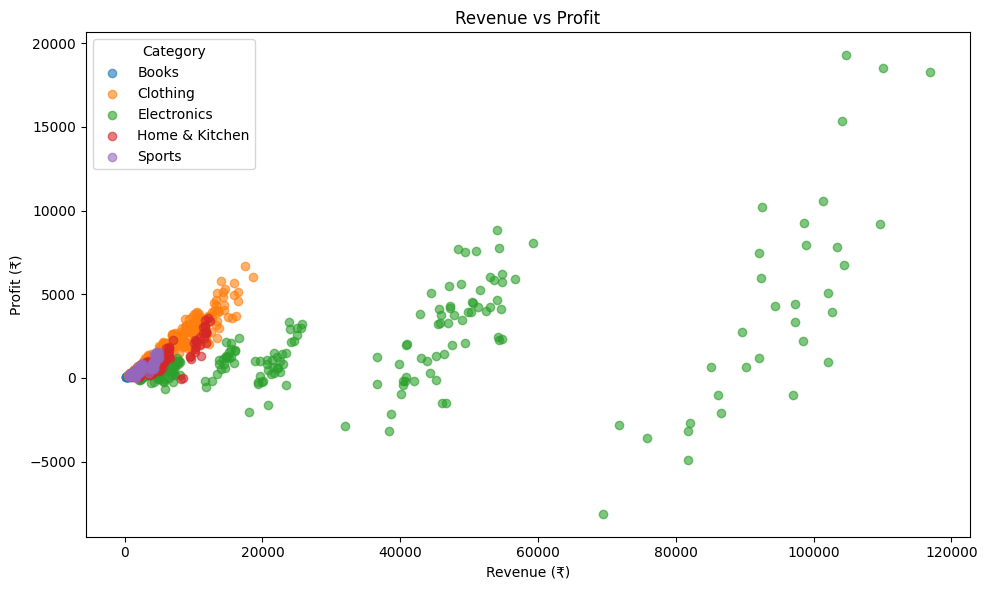

In [13]:
plt.figure(figsize=(10, 6))

for category, group in df.groupby("category"):
    plt.scatter(group["revenue"], group["profit"], alpha=0.6, label=category)

plt.xlabel("Revenue (₹)")
plt.ylabel("Profit (₹)")
plt.title("Revenue vs Profit")
plt.legend(title="Category")
plt.tight_layout()
plt.show()


### Q7. Grouped Bar Chart: Quarterly Revenue by Region

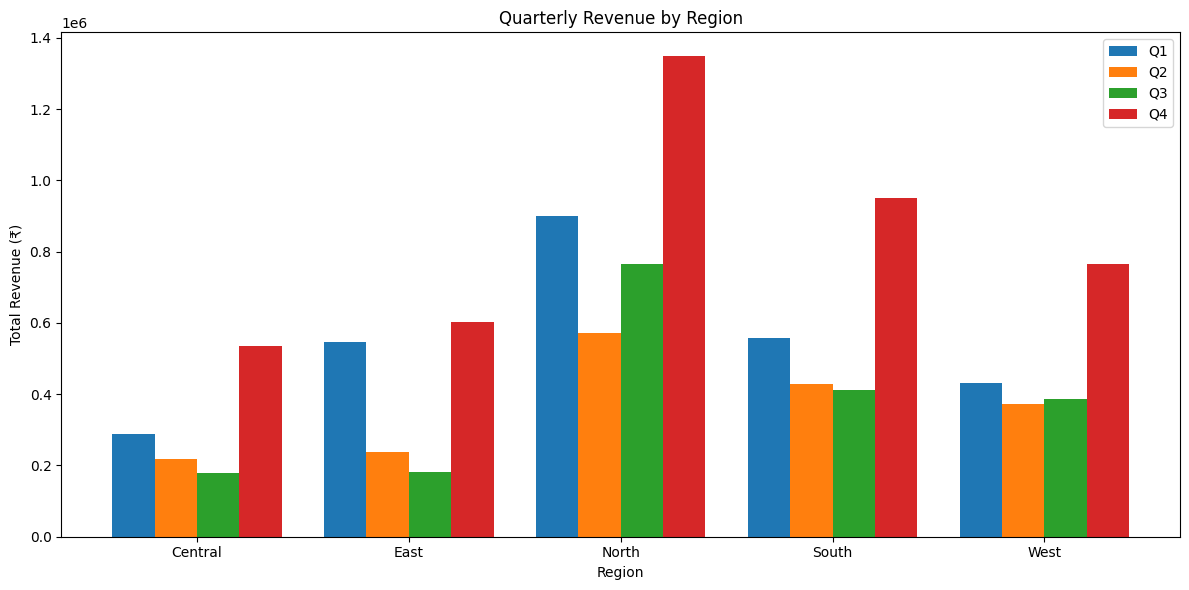

In [14]:
quarter_region = df.pivot_table(
    index="region", columns="quarter", values="revenue",
    aggfunc="sum", fill_value=0
).reindex(columns=[1, 2, 3, 4], fill_value=0)

regions = quarter_region.index
x = np.arange(len(regions))
width = 0.2

plt.figure(figsize=(12, 6))
for i, q in enumerate([1, 2, 3, 4]):
    plt.bar(x + (i - 1.5) * width, quarter_region[q],
            width, label=f"Q{q}")

plt.xticks(x, regions)
plt.xlabel("Region")
plt.ylabel("Total Revenue (₹)")
plt.title("Quarterly Revenue by Region")
plt.legend()
plt.tight_layout()
plt.show()


### Q8. Stacked Bar Chart: Monthly Orders by Category

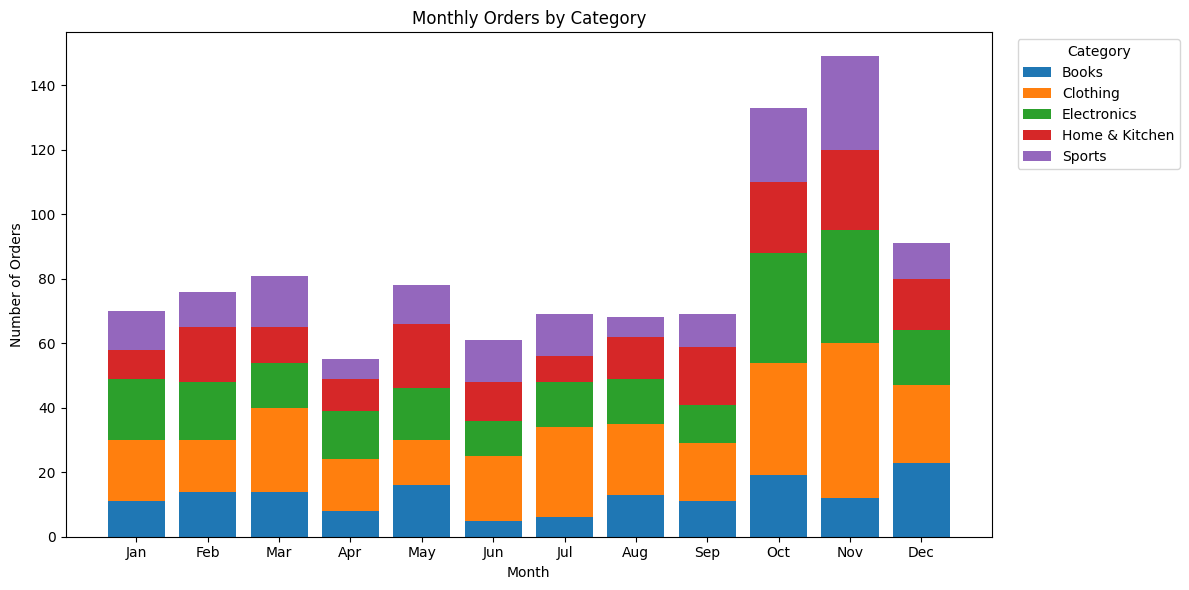

In [15]:
monthly_category = pd.crosstab(df["month"], df["category"]).reindex(range(1, 13), fill_value=0)
bottom = np.zeros(12)

plt.figure(figsize=(12, 6))
for category in monthly_category.columns:
    values = monthly_category[category].values
    plt.bar(month_names, values, bottom=bottom, label=category)
    bottom += values

plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.title("Monthly Orders by Category")
plt.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### Q9. Box Plot: Ratings by Category

/tmp/ipykernel_1342/1739796983.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(rating_data, labels=categories, showmeans=True)


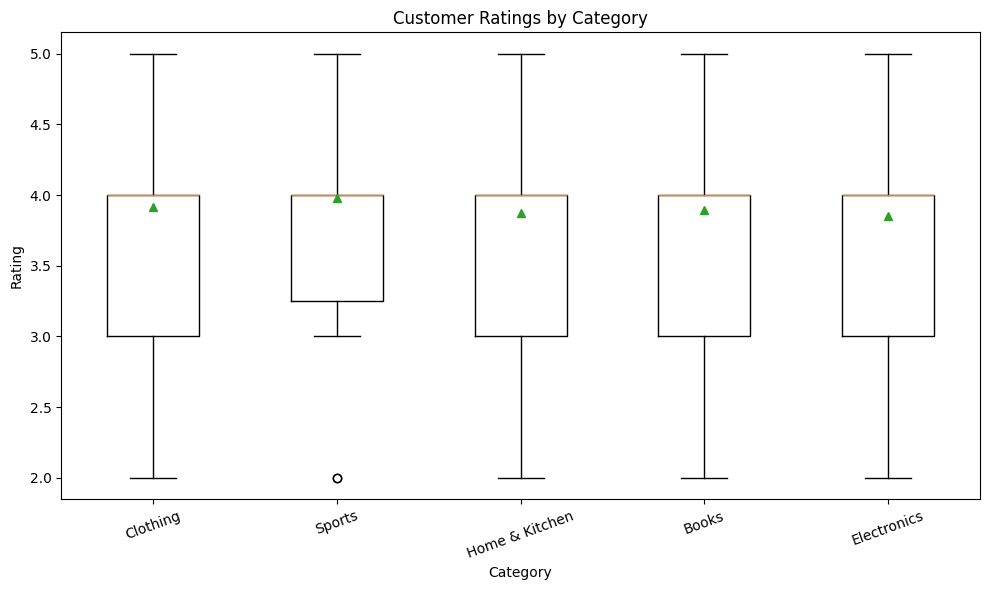

In [16]:
categories = df["category"].unique()
rating_data = [df.loc[df["category"] == c, "rating"] for c in categories]

plt.figure(figsize=(10, 6))
plt.boxplot(rating_data, labels=categories, showmeans=True)
plt.xlabel("Category")
plt.ylabel("Rating")
plt.title("Customer Ratings by Category")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


### Q10. Subplots — 2×2 Grid

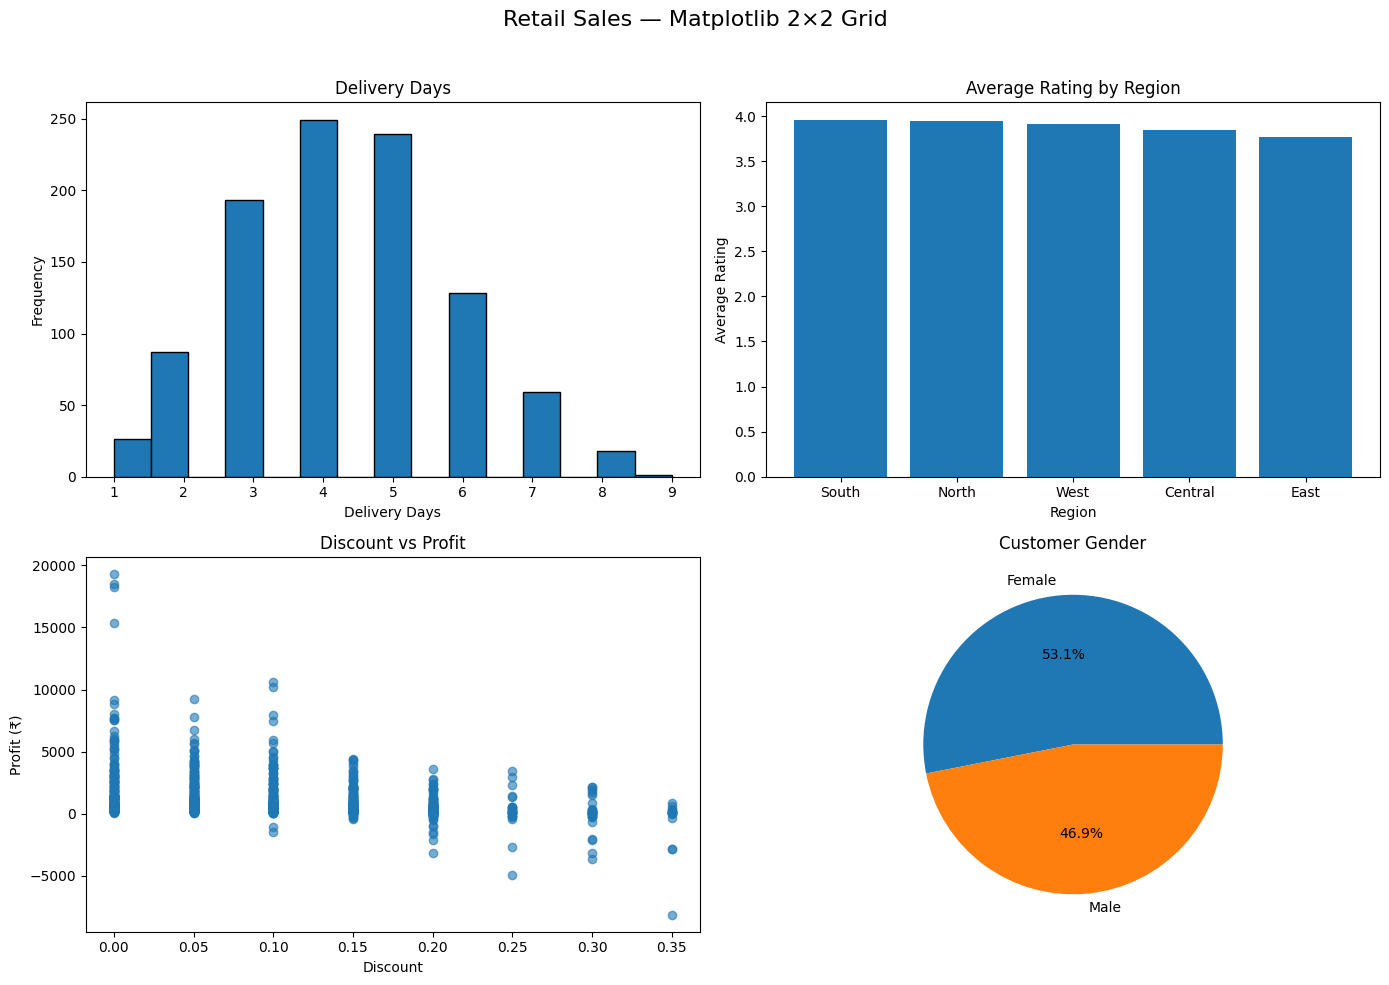

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) Histogram of delivery_days
axes[0, 0].hist(df["delivery_days"], bins=15, edgecolor="black")
axes[0, 0].set_title("Delivery Days")
axes[0, 0].set_xlabel("Delivery Days")
axes[0, 0].set_ylabel("Frequency")

# (b) Average rating by region
avg_rating_region = df.groupby("region")["rating"].mean().sort_values(ascending=False)
axes[0, 1].bar(avg_rating_region.index, avg_rating_region.values)
axes[0, 1].set_title("Average Rating by Region")
axes[0, 1].set_xlabel("Region")
axes[0, 1].set_ylabel("Average Rating")

# (c) Discount vs profit
axes[1, 0].scatter(df["discount"], df["profit"], alpha=0.6)
axes[1, 0].set_title("Discount vs Profit")
axes[1, 0].set_xlabel("Discount")
axes[1, 0].set_ylabel("Profit (₹)")

# (d) Customer gender
gender_counts = df["customer_gender"].value_counts()
axes[1, 1].pie(gender_counts.values, labels=gender_counts.index, autopct="%.1f%%")
axes[1, 1].set_title("Customer Gender")

fig.suptitle("Retail Sales — Matplotlib 2×2 Grid", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig("matplotlib_grid.png", dpi=300, bbox_inches="tight")
plt.show()
